# Food Spoilage Prediction using E-Nose Sensor Data

Notebook ini dibuat dengan script generator supaya file notebook pasti terbentuk dengan isi yang lengkap. Seluruh alur ada di satu notebook terintegrasi: EDA, preprocessing, training, evaluasi, dan demo inferensi.

## 1. Konfigurasi dan Inisialisasi

Bagian ini menyiapkan semua library, path, dan konfigurasi global. Konfigurasi didefinisikan dulu supaya proses bisa direproduksi dengan seed yang sama, split data yang konsisten, dan parameter model yang terdokumentasi jelas.

In [12]:
# --- Inline project configuration (moved from config.py) ---
from pathlib import Path
project_root = Path().resolve().parent

# Paths
RAW_DATA_FILE = project_root / "data" / "raw" / "train.csv"
PROCESSED_DATA_FILE = project_root / "data" / "processed" / "dataset_prepared.csv"
RSL_MODEL_FILE = project_root / "models" / "rsl_model.pkl"
CLASS_MODEL_FILE = project_root / "models" / "class_model.pkl"
RSL_METRICS_FILE = project_root / "results" / "rsl_metrics.txt"
CLASS_METRICS_FILE = project_root / "results" / "class_metrics.txt"

# Sensors / features
SENSOR_COLUMNS = ["Mq-135", "Mq-136", "Temperature", "Humidity"]
FEATURES = SENSOR_COLUMNS.copy()

# Targets and auxiliary columns
TARGET_RSL = "RSL_minutes"
TARGET_CLASS = "class"
MINUTES_COLUMN = "minutes"
TVC_COLUMN = "tvc"

# TVC-based class thresholds (3 classes):
# Class 1: Safe  -> TVC <= 4.0
# Class 2: Warning -> 4.0 < TVC < 5.0
# Class 3: Danger -> TVC >= 5.0
CLASS_TVC_RANGES = {
    1: (float('-inf'), 4.0),
    2: (4.0, 5.0),
    3: (5.0, float('inf'))
}
CLASS_NAMES = ['Safe', 'Warning', 'Danger']

# Spoilage minute used to derive RSL
SPOILAGE_MINUTE = 626

# Training split (time-aware)
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_SEED = 42

# Minimum sensor validation
MIN_SENSOR_VALUES = {"Mq-135": 0.1, "Mq-136": 0.1, "Temperature": -10, "Humidity": 0}

# Model parameters
XGBOOST_RSL_PARAMS = {
    "objective": "reg:squarederror",
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 200,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": RANDOM_SEED,
    "verbosity": 1,
}

XGBOOST_CLASS_PARAMS = {
    "objective": "multi:softmax",
    "num_class": 3,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_estimators": 200,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": RANDOM_SEED,
    "verbosity": 1,
}

# Class weights (index 0..2 correspond to Class 1..3 after -1 mapping)
CLASS_WEIGHTS_DICT = {0: 1.0, 1: 1.0, 2: 0.5}

import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Inline configuration loaded in notebook.')
print(f'Features: {FEATURES}')
print(f'Class names: {CLASS_NAMES}')

Inline configuration loaded in notebook.
Features: ['Mq-135', 'Mq-136', 'Temperature', 'Humidity']
Class names: ['Safe', 'Warning', 'Danger']


## 2. Pemuatan dan Eksplorasi Data

Bagian ini membaca dataset raw, menampilkan bentuk data, tipe data, ringkasan statistik, dan memeriksa nilai kosong. Tujuannya adalah memahami struktur data sebelum dilakukan cleaning dan feature engineering.

In [13]:
df_raw = pd.read_csv(RAW_DATA_FILE)

print('Shape data raw:', df_raw.shape)
print('Nama kolom:')
for idx, col in enumerate(df_raw.columns, 1):
    print(f'{idx}. {col}')

print('\nInfo data:')
print(df_raw.info())

print('\nStatistik deskriptif:')
print(df_raw.describe())

print('\nMissing values per kolom:')
print(df_raw.isnull().sum())

Shape data raw: (20815, 14)
Nama kolom:
1. sl no
2. minutes
3. Temperature
4. Humidity
5. Mq-2 
6. Mq-3 
7. Mq-4 
8. Mq-5 
9. Mq-135
10. Mq-136
11. Mq-137
12. Mq-138
13. class
14. tvc

Info data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20815 entries, 0 to 20814
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sl no        20815 non-null  int64  
 1   minutes      20815 non-null  int64  
 2   Temperature  20815 non-null  float64
 3   Humidity     20815 non-null  float64
 4   Mq-2         20815 non-null  int64  
 5   Mq-3         20815 non-null  int64  
 6   Mq-4         20815 non-null  int64  
 7   Mq-5         20815 non-null  int64  
 8   Mq-135       20815 non-null  int64  
 9   Mq-136       20815 non-null  int64  
 10  Mq-137       20815 non-null  int64  
 11  Mq-138       20815 non-null  int64  
 12  class        20815 non-null  int64  
 13  tvc          20815 non-null  float64
dtypes: float64(3), int

In [14]:
# === Diagnostic: RSL Model Learning Check (dengan class feature) ===
# Load models and regenerate predictions if variables not in memory
try:
    _ = (y_rsl_test, rsl_test_pred, y_class_test)
except NameError:
    print('⚠️ Variabel evaluasi belum terdefinisi — memuat model dan menghitung ulang prediksi...')
    if not RSL_MODEL_FILE.exists() or not CLASS_MODEL_FILE.exists():
        print('❌ File model tidak ditemukan. Jalankan sel pelatihan terlebih dahulu.')
    else:
        try:
            # Load models
            with open(RSL_MODEL_FILE, 'rb') as f:
                rsl_payload = pickle.load(f)
            with open(CLASS_MODEL_FILE, 'rb') as f:
                class_payload = pickle.load(f)
            
            model_rsl = rsl_payload['model']
            scaler_rsl = rsl_payload['scaler_sensors']
            model_class = class_payload['model']
            scaler_class = class_payload['scaler']
            
            # Load processed data and recreate splits
            df_processed = pd.read_csv(PROCESSED_DATA_FILE)
            X_proc = df_processed[FEATURES].copy()
            y_class_proc = df_processed[TARGET_CLASS].copy() - 1
            y_rsl_proc = df_processed[TARGET_RSL].copy()
            
            # Recreate test split
            X_train_val, X_test, y_class_train_val, y_class_test = train_test_split(
                X_proc, y_class_proc, test_size=TEST_RATIO, random_state=RANDOM_SEED, stratify=y_class_proc
            )
            y_rsl_test = y_rsl_proc.loc[X_test.index]
            
            # Generate predictions
            X_test_scaled = scaler_class.transform(X_test)
            class_test_pred = model_class.predict(X_test_scaled)
            
            X_test_sensors_scaled = scaler_rsl.transform(X_test)
            X_test_with_class = np.column_stack([X_test_sensors_scaled, class_test_pred])
            rsl_test_pred = model_rsl.predict(X_test_with_class)
            
            print('✓ Model dimuat dan prediksi dihitung ulang.')
        except Exception as e:
            print(f'❌ Error saat memuat model: {e}')

if 'y_class_test' in locals() and 'rsl_test_pred' in locals() and 'y_rsl_test' in locals():
    print("📊 RSL MODEL PREDICTION CHECK (class sebagai feature)")
    print("=" * 70)
    
    # Check if Danger rows now get RSL ≈ 0
    for cls_idx in sorted(np.unique(y_class_test)):
        mask = y_class_test == cls_idx
        pred = rsl_test_pred[mask]
        actual = y_rsl_test.values[mask]
        cls_name = CLASS_NAMES[int(cls_idx)]
        
        print(f"\nClass {int(cls_idx)} ({cls_name}):")
        print(f"  Sample count: {mask.sum()}")
        print(f"  Actual RSL: mean={actual.mean():.2f}, min={actual.min():.0f}, max={actual.max():.0f}")
        print(f"  Pred RSL:   mean={pred.mean():.2f}, min={pred.min():.2f}, max={pred.max():.2f}")
        print(f"  MAE: {np.abs(pred - actual).mean():.4f}")
        
        if cls_idx == 2:  # Danger class
            danger_pred_zero = (pred == 0).sum()
            danger_pred_near_zero = (pred < 1).sum()
            print(f"  ✓ Danger predictions == 0: {danger_pred_zero} ({danger_pred_zero/mask.sum()*100:.1f}%)")
            print(f"  ✓ Danger predictions < 1: {danger_pred_near_zero} ({danger_pred_near_zero/mask.sum()*100:.1f}%)")
    
    print("\n" + "=" * 70)
else:
    print('❌ Tidak dapat menampilkan diagnostic — variabel tidak tersedia.')


📊 RSL MODEL PREDICTION CHECK (class sebagai feature)

Class 0 (Safe):
  Sample count: 417
  Actual RSL: mean=313.94, min=193, max=625
  Pred RSL:   mean=0.00, min=0.00, max=0.00
  MAE: 313.9353

Class 1 (Warning):
  Sample count: 344
  Actual RSL: mean=91.59, min=1, max=191
  Pred RSL:   mean=0.00, min=0.00, max=0.00
  MAE: 91.5872

Class 2 (Danger):
  Sample count: 1998
  Actual RSL: mean=0.00, min=0, max=0
  Pred RSL:   mean=0.00, min=0.00, max=0.00
  MAE: 0.0000
  ✓ Danger predictions == 0: 1998 (100.0%)
  ✓ Danger predictions < 1: 1998 (100.0%)



## 3. Pra-pemrosesan Data dan Rekayasa Fitur

Langkah ini menyeleksi kolom yang relevan, menghapus baris dengan nilai sensor yang kosong atau tidak valid, menurunkan kolom RSL dari kolom minutes, lalu **membentuk label class langsung dari nilai TVC**. Hasil akhirnya disimpan sebagai CSV processed agar bisa dipakai ulang oleh script training.

In [15]:
# --- Preprocessing: select columns, clean, derive RSL and class from TVC ---
columns_to_keep = SENSOR_COLUMNS + [MINUTES_COLUMN, TVC_COLUMN]
df = df_raw[columns_to_keep].copy()

print('Kolom yang dipakai:', columns_to_keep)
print('Shape setelah seleksi kolom:', df.shape)

rows_before = len(df)
df = df.dropna()
print('Rows setelah drop missing:', len(df))
print('Rows dihapus karena missing:', rows_before - len(df))

for sensor, min_val in MIN_SENSOR_VALUES.items():
    if sensor in df.columns:
        rows_before_sensor = len(df)
        df = df[df[sensor] > min_val]
        removed = rows_before_sensor - len(df)
        if removed > 0:
            print(f'{sensor} rows dihapus:', removed)

# Derive RSL
df[TARGET_RSL] = (SPOILAGE_MINUTE - df[MINUTES_COLUMN]).clip(lower=0)

# Derive 3-class label from TVC: 1=Safe (TVC <= 4.0), 2=Warning (4.0 < TVC < 5.0), 3=Danger (TVC >=5.0)
def tvc_to_three_class(tvc_value):
    if tvc_value >= 5.0:
        return 3
    if tvc_value > 4.0:
        return 2
    return 1

df[TARGET_CLASS] = df[TVC_COLUMN].apply(tvc_to_three_class).astype(int)

print('Aturan class dari TVC (3 classes):')
print('  1: Safe  -> TVC <= 4.0')
print('  2: Warning -> 4.0 < TVC < 5.0')
print('  3: Danger -> TVC >= 5.0')

print('Shape final setelah preprocessing:', df.shape)
print(df[[MINUTES_COLUMN, TVC_COLUMN, TARGET_RSL, TARGET_CLASS]].head())
print('Distribusi class hasil derivasi TVC:')
print(df[TARGET_CLASS].value_counts().sort_index())

PROCESSED_DATA_FILE.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED_DATA_FILE, index=False)
print('File processed disimpan ke:', PROCESSED_DATA_FILE)

Kolom yang dipakai: ['Mq-135', 'Mq-136', 'Temperature', 'Humidity', 'minutes', 'tvc']
Shape setelah seleksi kolom: (20815, 6)
Rows setelah drop missing: 20815
Rows dihapus karena missing: 0
Mq-135 rows dihapus: 2425
Humidity rows dihapus: 1
Aturan class dari TVC (3 classes):
  1: Safe  -> TVC <= 4.0
  2: Warning -> 4.0 < TVC < 5.0
  3: Danger -> TVC >= 5.0
Shape final setelah preprocessing: (18389, 8)
   minutes    tvc  RSL_minutes  class
0        1  2.002          625      1
1        1  2.002          625      1
2        1  2.002          625      1
3        1  2.002          625      1
4        1  2.002          625      1
Distribusi class hasil derivasi TVC:
class
1     2782
2     2292
3    13315
Name: count, dtype: int64
File processed disimpan ke: C:\Coding\reksti\Reksti_FreshGuard\Food-Spoilage-Prediction-master\Food-Spoilage-Prediction-master\data\processed\dataset_prepared.csv


## 4. Analisis Data Eksploratif

Bagian ini menampilkan distribusi kelas, distribusi sensor, scatter plot fitur terhadap target, time series plot, dan korelasi antar fitur. Visualisasi ini membantu kita memahami imbalance dan pola perubahan data dari waktu ke waktu.

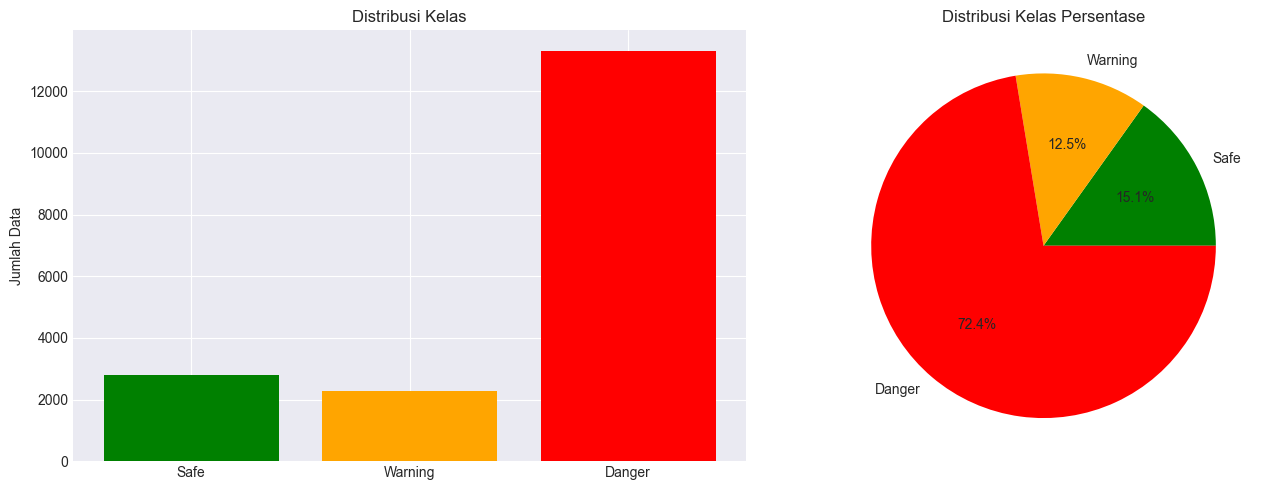

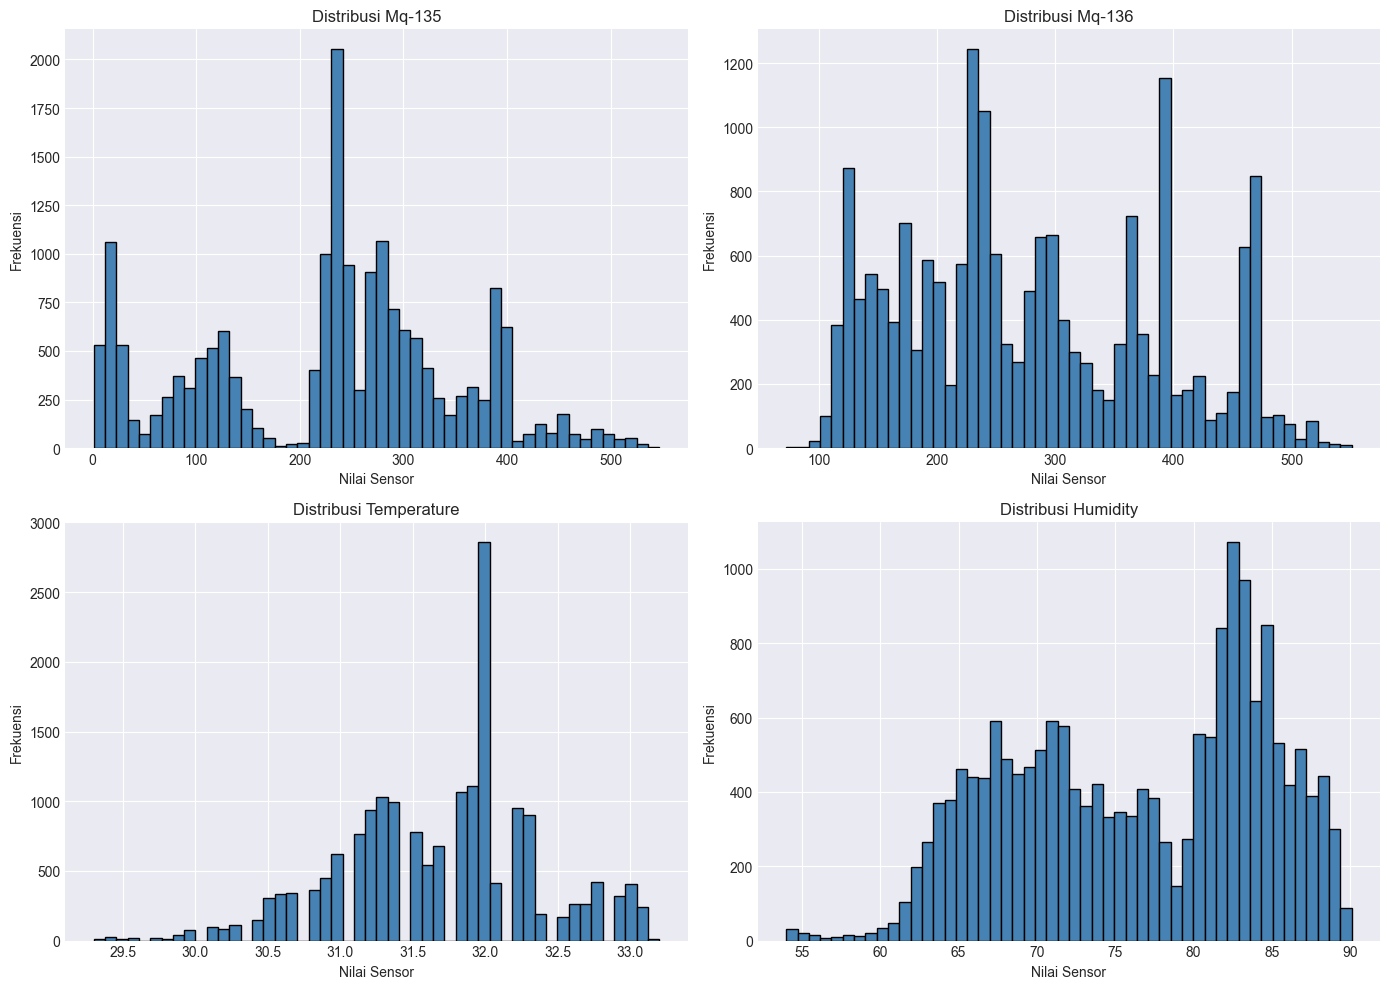

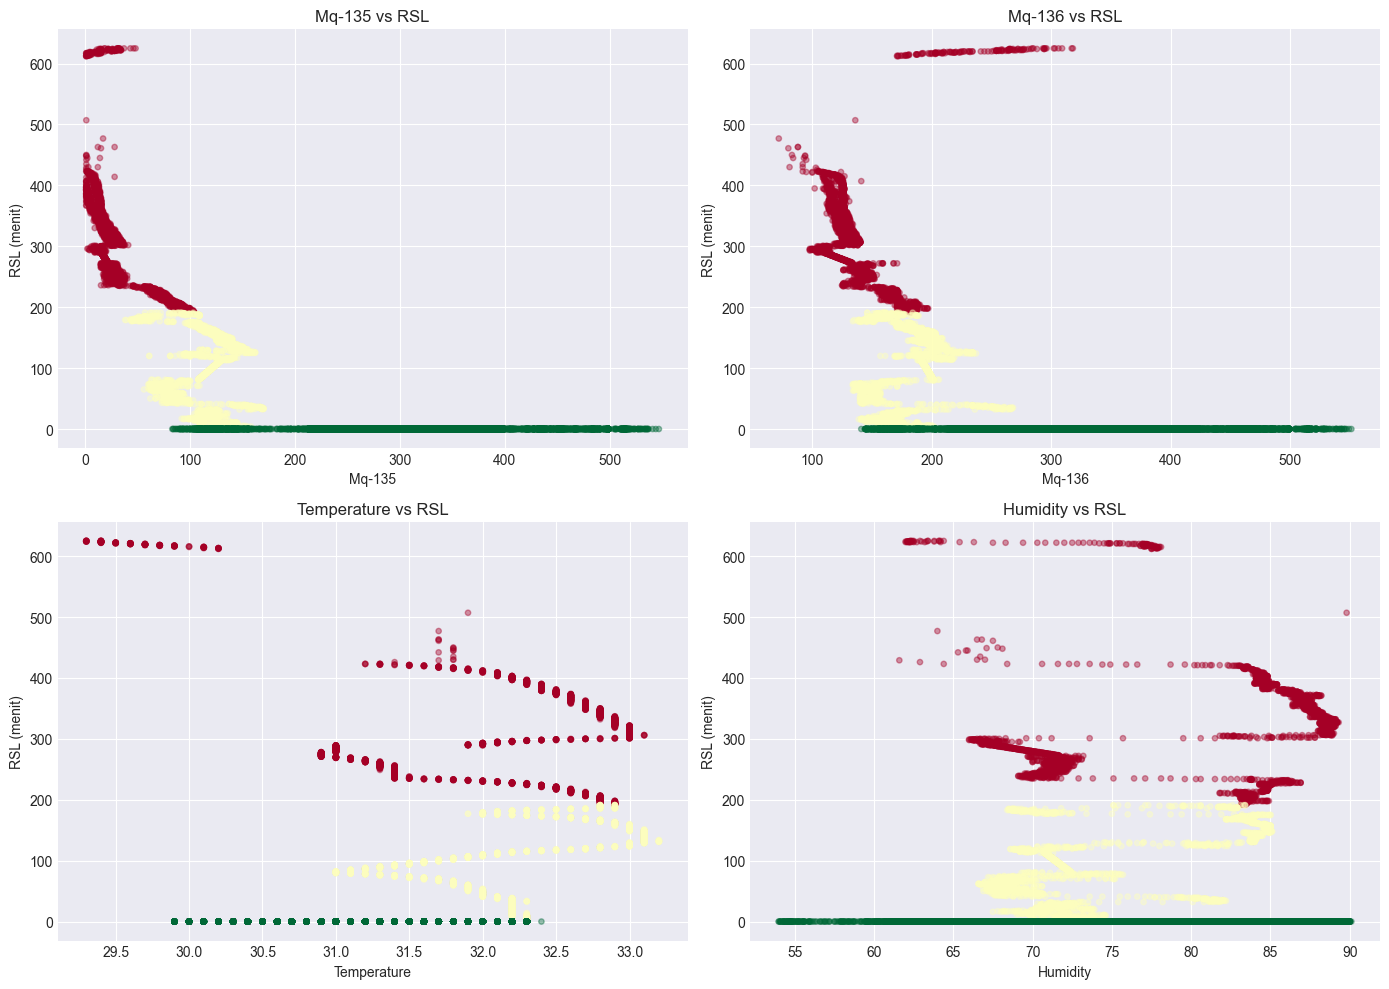

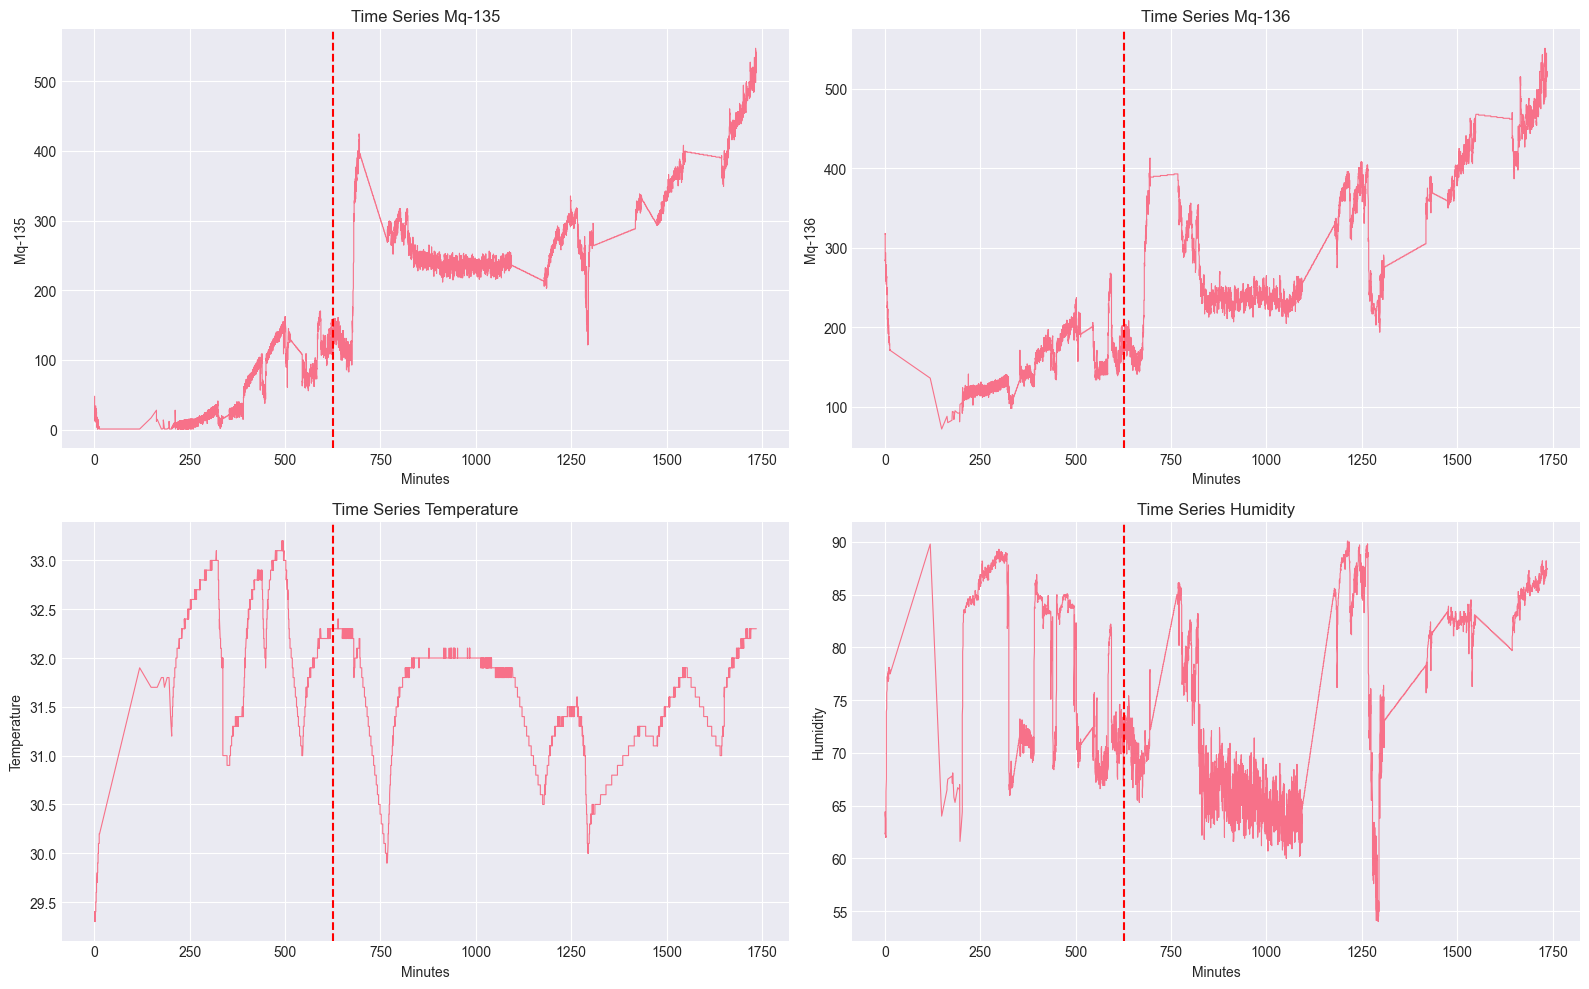

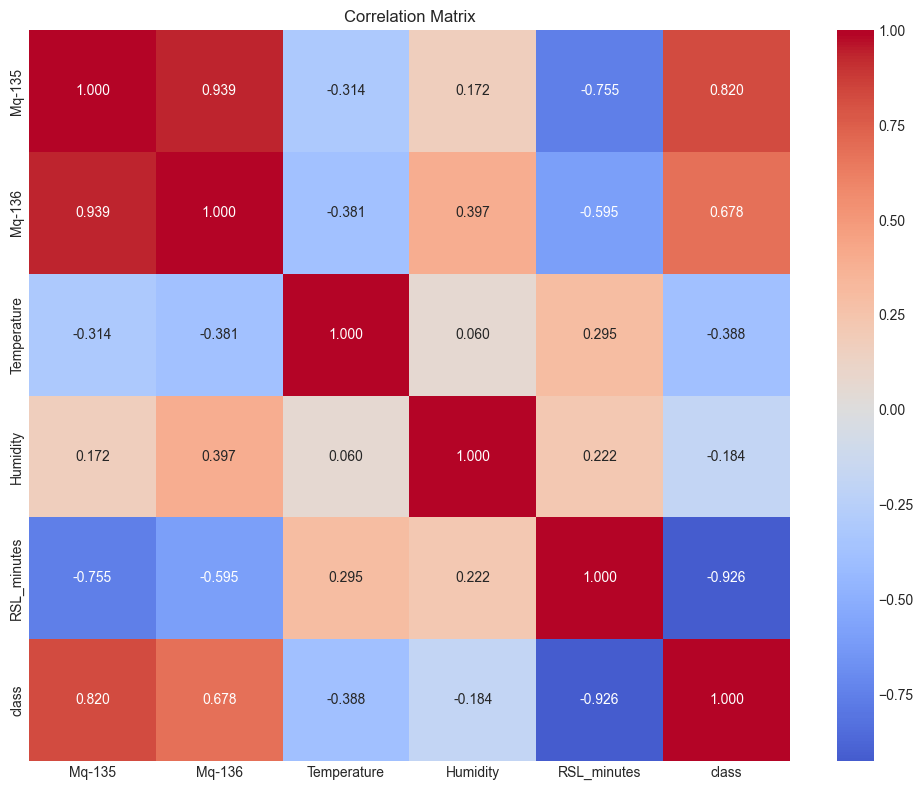

Korelasi dengan RSL:
RSL_minutes    1.000000
Temperature    0.294582
Humidity       0.222038
Mq-136        -0.595404
Mq-135        -0.754943
class         -0.925780
Name: RSL_minutes, dtype: float64


In [16]:
# Plot distribusi kelas menggunakan `CLASS_NAMES` (3 kelas)
class_counts = df[TARGET_CLASS].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['green', 'orange', 'red']
axes[0].bar(class_counts.index, class_counts.values, color=colors[:len(class_counts)])
axes[0].set_xticks(list(class_counts.index))
axes[0].set_xticklabels([CLASS_NAMES[i-1] for i in class_counts.index])
axes[0].set_title('Distribusi Kelas')
axes[0].set_ylabel('Jumlah Data')

class_pct = df[TARGET_CLASS].value_counts(normalize=True).sort_index() * 100
axes[1].pie(class_pct.values, labels=[CLASS_NAMES[i-1] for i in class_pct.index], autopct='%1.1f%%', colors=colors[:len(class_pct)])
axes[1].set_title('Distribusi Kelas Persentase')
plt.tight_layout()
plt.show()

# Distribusi sensor
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, sensor in enumerate(SENSOR_COLUMNS):
    axes[idx].hist(df[sensor], bins=50, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'Distribusi {sensor}')
    axes[idx].set_xlabel('Nilai Sensor')
    axes[idx].set_ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# Scatter sensor vs RSL (warna berdasarkan class)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, sensor in enumerate(SENSOR_COLUMNS):
    axes[idx].scatter(df[sensor], df[TARGET_RSL], alpha=0.4, s=15, c=df[TARGET_CLASS], cmap='RdYlGn', vmin=1, vmax=3)
    axes[idx].set_title(f'{sensor} vs RSL')
    axes[idx].set_xlabel(sensor)
    axes[idx].set_ylabel('RSL (menit)')
plt.tight_layout()
plt.show()

# Time series sensor
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for idx, sensor in enumerate(SENSOR_COLUMNS):
    axes[idx].plot(df[MINUTES_COLUMN], df[sensor], linewidth=0.8)
    axes[idx].axvline(x=SPOILAGE_MINUTE, color='red', linestyle='--')
    axes[idx].set_title(f'Time Series {sensor}')
    axes[idx].set_xlabel('Minutes')
    axes[idx].set_ylabel(sensor)
plt.tight_layout()
plt.show()

# Korelasi
corr_cols = SENSOR_COLUMNS + [TARGET_RSL, TARGET_CLASS]
corr = df[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print('Korelasi dengan RSL:')
print(corr[TARGET_RSL].sort_values(ascending=False))

## 5. Persiapan Data untuk Model

Di bagian ini kita melakukan stratified split supaya distribusi kelas tetap seimbang di train, validation, dan test. Fitur input kemudian di-scale memakai StandardScaler. Untuk klasifikasi, class imbalance ditangani dengan class weights.

In [17]:
X = df[FEATURES].copy()
y_rsl = df[TARGET_RSL].copy()
y_class = df[TARGET_CLASS].copy() - 1

# Create X_rsl with class as additional feature (for RSL model training)
# Class values: 1, 2, 3 → we'll use 0, 1, 2 (same as y_class)
X_rsl = X.copy()
X_rsl['class'] = y_class.values

total_samples = len(df)
train_split = int(total_samples * TRAIN_RATIO)
val_split = int(total_samples * (TRAIN_RATIO + VAL_RATIO))

X_train_val, X_test, y_class_train_val, y_class_test = train_test_split(
    X,
    y_class,
    test_size=TEST_RATIO,
    random_state=RANDOM_SEED,
    stratify=y_class
)

val_size_relative = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
X_train, X_val, y_class_train, y_class_val = train_test_split(
    X_train_val,
    y_class_train_val,
    test_size=val_size_relative,
    random_state=RANDOM_SEED,
    stratify=y_class_train_val
)

# Also split X_rsl (with class feature) for RSL training
X_rsl_train = X_rsl.loc[X_train.index].copy()
X_rsl_val = X_rsl.loc[X_val.index].copy()
X_rsl_test = X_rsl.loc[X_test.index].copy()

y_rsl_train = y_rsl.loc[X_train.index]
y_rsl_val = y_rsl.loc[X_val.index]
y_rsl_test = y_rsl.loc[X_test.index]

print('Total samples:', len(df))
print('Train shape:', X_train.shape)
print('Validation shape:', X_val.shape)
print('Test shape:', X_test.shape)
print('Class distribution in train set:')
print(y_class_train.value_counts().sort_index())
print('Class distribution in validation set:')
print(y_class_val.value_counts().sort_index())
print('Class distribution in test set:')
print(y_class_test.value_counts().sort_index())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# For RSL model, scale X_rsl separately (will include class feature)
# Note: we scale only sensor features, class is added after scaling
scaler_rsl = StandardScaler()
X_rsl_train_sensors = scaler_rsl.fit_transform(X_rsl_train[SENSOR_COLUMNS])
X_rsl_val_sensors = scaler_rsl.transform(X_rsl_val[SENSOR_COLUMNS])
X_rsl_test_sensors = scaler_rsl.transform(X_rsl_test[SENSOR_COLUMNS])

# Add class feature (not scaled, use 0/1/2 directly)
X_rsl_train_scaled = np.column_stack([X_rsl_train_sensors, X_rsl_train['class'].values])
X_rsl_val_scaled = np.column_stack([X_rsl_val_sensors, X_rsl_val['class'].values])
X_rsl_test_scaled = np.column_stack([X_rsl_test_sensors, X_rsl_test['class'].values])

sample_weights = np.zeros(len(y_class_train))
for idx, label in enumerate(y_class_train):
    sample_weights[idx] = CLASS_WEIGHTS_DICT[int(label)]

print('\nUnique sample weights:', np.unique(sample_weights))
print('RSL model will use', X_rsl_train_scaled.shape[1], 'features: [4 sensors + 1 class]')

Total samples: 18389
Train shape: (12871, 4)
Validation shape: (2759, 4)
Test shape: (2759, 4)
Class distribution in train set:
class
0    1948
1    1604
2    9319
Name: count, dtype: int64
Class distribution in validation set:
class
0     417
1     344
2    1998
Name: count, dtype: int64
Class distribution in test set:
class
0     417
1     344
2    1998
Name: count, dtype: int64

Unique sample weights: [0.5 1. ]
RSL model will use 5 features: [4 sensors + 1 class]


## 6. Pelatihan Model Regresi RSL

Model pertama adalah XGBoost Regressor untuk memprediksi Remaining Shelf Life dalam menit. Hyperparameter disimpan di konfigurasi agar pelatihan mudah diulang dengan hasil yang konsisten.

In [18]:
model_rsl = xgb.XGBRegressor(**XGBOOST_RSL_PARAMS)
model_rsl.fit(X_rsl_train_scaled, y_rsl_train, eval_set=[(X_rsl_val_scaled, y_rsl_val)], verbose=False)

rsl_train_pred = model_rsl.predict(X_rsl_train_scaled)
rsl_val_pred = model_rsl.predict(X_rsl_val_scaled)
rsl_test_pred = model_rsl.predict(X_rsl_test_scaled)

rsl_train_mae = mean_absolute_error(y_rsl_train, rsl_train_pred)
rsl_val_mae = mean_absolute_error(y_rsl_val, rsl_val_pred)
rsl_test_mae = mean_absolute_error(y_rsl_test, rsl_test_pred)

rsl_train_rmse = np.sqrt(mean_squared_error(y_rsl_train, rsl_train_pred))
rsl_val_rmse = np.sqrt(mean_squared_error(y_rsl_val, rsl_val_pred))
rsl_test_rmse = np.sqrt(mean_squared_error(y_rsl_test, rsl_test_pred))

rsl_train_r2 = r2_score(y_rsl_train, rsl_train_pred)
rsl_val_r2 = r2_score(y_rsl_val, rsl_val_pred)
rsl_test_r2 = r2_score(y_rsl_test, rsl_test_pred)

print('Validasi RSL (dengan class feature) - MAE:', round(rsl_val_mae, 4))
print('Validasi RSL - RMSE:', round(rsl_val_rmse, 4))
print('Validasi RSL - R2:', round(rsl_val_r2, 4))
print('Test RSL - MAE:', round(rsl_test_mae, 4))
print('Test RSL - RMSE:', round(rsl_test_rmse, 4))
print('Test RSL - R2:', round(rsl_test_r2, 4))

rsl_model_payload = {
    'model': model_rsl,
    'scaler_sensors': scaler_rsl,  # Scaler untuk 4 sensor features
    'features': SENSOR_COLUMNS,     # Original 4 sensor features
    'hyperparameters': XGBOOST_RSL_PARAMS,
    'note': 'Model expects [scaled_sensors (4 features) + class (1 feature)]',
}
with open(RSL_MODEL_FILE, 'wb') as f:
    pickle.dump(rsl_model_payload, f)

rsl_metrics_text = '\n'.join([
    'RSL REGRESSION MODEL (dengan class sebagai feature)',
    f'Features: {SENSOR_COLUMNS} + class (0/1/2)',
    f'Train MAE: {rsl_train_mae:.4f}',
    f'Val MAE: {rsl_val_mae:.4f}',
    f'Test MAE: {rsl_test_mae:.4f}',
    f'Train RMSE: {rsl_train_rmse:.4f}',
    f'Val RMSE: {rsl_val_rmse:.4f}',
    f'Test RMSE: {rsl_test_rmse:.4f}',
    f'Train R2: {rsl_train_r2:.4f}',
    f'Val R2: {rsl_val_r2:.4f}',
    f'Test R2: {rsl_test_r2:.4f}',
    f'Hyperparameters: {XGBOOST_RSL_PARAMS}',
])
RSL_METRICS_FILE.parent.mkdir(parents=True, exist_ok=True)
with open(RSL_METRICS_FILE, 'w', encoding='utf-8') as f:
    f.write(rsl_metrics_text)

Validasi RSL (dengan class feature) - MAE: 0.9991
Validasi RSL - RMSE: 3.9957
Validasi RSL - R2: 0.9989
Test RSL - MAE: 1.0486
Test RSL - RMSE: 3.8816
Test RSL - R2: 0.9989


## 7. Pelatihan Model Klasifikasi Kesegaran

Model kedua adalah XGBoost Classifier untuk memprediksi kelas kesegaran daging. Karena data imbalance, training memakai sample weights agar model tidak terlalu condong ke kelas 4 yang dominan.

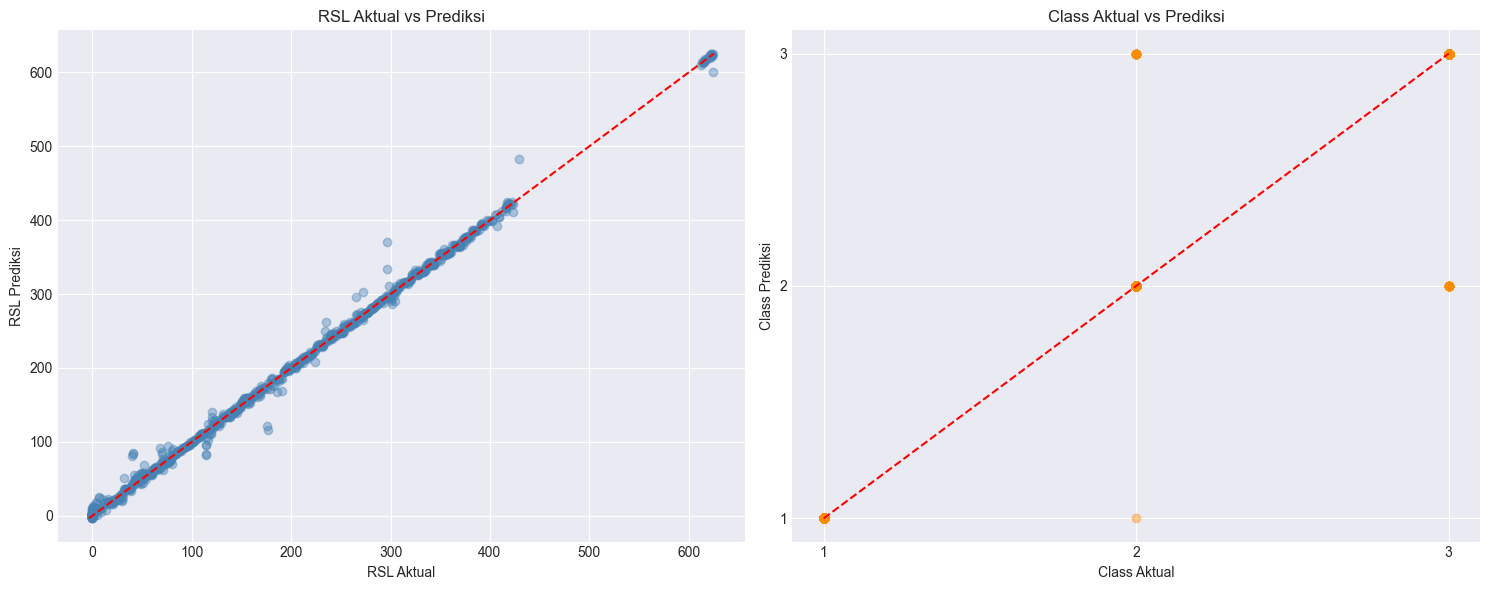

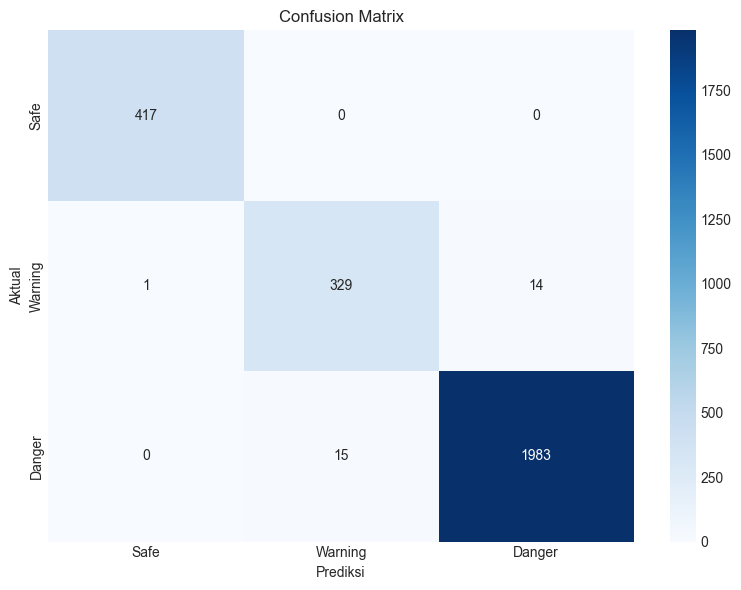

RSL Metrics Test
MAE: 1.0486
RMSE: 3.8816
R2: 0.9989

Class Metrics Test
Accuracy: 0.9891
F1 Macro: 0.9826
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00       417
     Warning       0.96      0.96      0.96       344
      Danger       0.99      0.99      0.99      1998

    accuracy                           0.99      2759
   macro avg       0.98      0.98      0.98      2759
weighted avg       0.99      0.99      0.99      2759



In [23]:
# Plot results (safe if training variables are missing; will attempt to load models from disk)
try:
    need_reload = False
    # check common variables
    _ = (y_rsl_test, rsl_test_pred)
    _ = (y_class_test, class_test_pred, class_cm, class_test_acc, class_test_f1, class_report)
except Exception:
    need_reload = True

if need_reload:
    print('Beberapa variabel evaluasi tidak ditemukan di memori — mencoba memuat model dan menghitung ulang prediksi dari file...')
    import os
    if not RSL_MODEL_FILE.exists() or not CLASS_MODEL_FILE.exists():
        print('File model tidak ditemukan. Jalankan sel pelatihan terlebih dahulu atau letakkan model di:', RSL_MODEL_FILE, CLASS_MODEL_FILE)
    else:
        with open(RSL_MODEL_FILE, 'rb') as f:
            rsl_payload = pickle.load(f)
        with open(CLASS_MODEL_FILE, 'rb') as f:
            class_payload = pickle.load(f)
        rsl_model = rsl_payload['model']
        rsl_scaler = rsl_payload.get('scaler', None)
        class_model = class_payload['model']
        class_scaler = class_payload.get('scaler', None)
        try:
            X_test_in = X_test.copy()
            X_test_scaled_local = rsl_scaler.transform(X_test_in) if rsl_scaler is not None else X_test_in.values
            rsl_test_pred = rsl_model.predict(X_test_scaled_local)
        except Exception as e:
            print('Gagal mem-prediksi RSL:', e)
            rsl_test_pred = np.zeros(len(X_test)) if 'X_test' in globals() else np.array([])
        try:
            X_test_scaled_c = class_scaler.transform(X_test_in) if class_scaler is not None else X_test_in.values
            class_test_pred = class_model.predict(X_test_scaled_c)
            class_proba_local = class_model.predict_proba(X_test_scaled_c)
            class_cm = confusion_matrix(y_class_test, class_test_pred) if 'y_class_test' in globals() else None
            class_test_acc = accuracy_score(y_class_test, class_test_pred) if 'y_class_test' in globals() else None
            class_test_f1 = f1_score(y_class_test, class_test_pred, average='macro') if 'y_class_test' in globals() else None
            class_report = classification_report(y_class_test, class_test_pred, labels=list(range(len(CLASS_NAMES))), target_names=CLASS_NAMES, zero_division=0) if 'y_class_test' in globals() else ''
        except Exception as e:
            print('Gagal mem-prediksi kelas:', e)
            class_test_pred = np.zeros(len(X_test), dtype=int) if 'X_test' in globals() else np.array([])
            class_cm = None
            class_test_acc = None
            class_test_f1 = None
            class_report = ''

# Now plot if arrays are available
if 'rsl_test_pred' in globals() and len(rsl_test_pred) > 0 and 'y_rsl_test' in globals():
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    axes[0].scatter(y_rsl_test, rsl_test_pred, alpha=0.4, color='steelblue')
    min_rsl = min(y_rsl_test.min(), rsl_test_pred.min())
    max_rsl = max(y_rsl_test.max(), rsl_test_pred.max())
    axes[0].plot([min_rsl, max_rsl], [min_rsl, max_rsl], 'r--')
    axes[0].set_title('RSL Aktual vs Prediksi')
    axes[0].set_xlabel('RSL Aktual')
    axes[0].set_ylabel('RSL Prediksi')
else:
    print('Tidak ada data RSL untuk diplot.')

if 'class_test_pred' in globals() and len(class_test_pred) > 0 and 'y_class_test' in globals():
    fig = None
    axes[1].scatter(y_class_test + 1, class_test_pred + 1, alpha=0.4, color='darkorange')
    axes[1].plot([1, len(CLASS_NAMES)], [1, len(CLASS_NAMES)], 'r--')
    axes[1].set_xticks(list(range(1, len(CLASS_NAMES)+1)))
    axes[1].set_yticks(list(range(1, len(CLASS_NAMES)+1)))
    axes[1].set_title('Class Aktual vs Prediksi')
    axes[1].set_xlabel('Class Aktual')
    axes[1].set_ylabel('Class Prediksi')
    plt.tight_layout()
    plt.show()
    if class_cm is not None:
        plt.figure(figsize=(8, 6))
        sns.heatmap(class_cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        plt.title('Confusion Matrix')
        plt.xlabel('Prediksi')
        plt.ylabel('Aktual')
        plt.tight_layout()
        plt.show()
    print('RSL Metrics Test')
    if 'rsl_test_mae' in globals():
        print('MAE:', round(rsl_test_mae, 4))
        print('RMSE:', round(rsl_test_rmse, 4))
        print('R2:', round(rsl_test_r2, 4))
    print('\nClass Metrics Test')
    print('Accuracy:', round(class_test_acc, 4) if class_test_acc is not None else 'N/A')
    print('F1 Macro:', round(class_test_f1, 4) if class_test_f1 is not None else 'N/A')
    print(class_report)
else:
    print('Tidak ada data klasifikasi untuk diplot. Jalankan sel pelatihan klasifikasi terlebih dahulu atau muat model yang sudah dilatih.')

## 8. Evaluasi dan Visualisasi Hasil

Bagian ini membandingkan prediksi dan nilai aktual untuk dua model. Visualisasi membantu kita melihat apakah model mengikuti pola data dan seberapa besar error yang masih tersisa.

In [20]:
# --- Train classification model (XGBoost) ---
model_class = xgb.XGBClassifier(**XGBOOST_CLASS_PARAMS)
model_class.fit(
    X_train_scaled,
    y_class_train,
    sample_weight=sample_weights,
    eval_set=[(X_val_scaled, y_class_val)],
    verbose=False,
 )

class_train_pred = model_class.predict(X_train_scaled)
class_val_pred = model_class.predict(X_val_scaled)
class_test_pred = model_class.predict(X_test_scaled)

class_train_acc = accuracy_score(y_class_train, class_train_pred)
class_val_acc = accuracy_score(y_class_val, class_val_pred)
class_test_acc = accuracy_score(y_class_test, class_test_pred)

class_train_f1 = f1_score(y_class_train, class_train_pred, average='macro')
class_val_f1 = f1_score(y_class_val, class_val_pred, average='macro')
class_test_f1 = f1_score(y_class_test, class_test_pred, average='macro')

class_cm = confusion_matrix(y_class_test, class_test_pred)
class_report = classification_report(y_class_test, class_test_pred, labels=[0, 1, 2], target_names=CLASS_NAMES, zero_division=0)

print('Validasi Class - Accuracy:', round(class_val_acc, 4))
print('Validasi Class - F1 macro:', round(class_val_f1, 4))
print('Test Class - Accuracy:', round(class_test_acc, 4))
print('Test Class - F1 macro:', round(class_test_f1, 4))
print('Confusion Matrix Test:')
print(class_cm)

class_model_payload = {
    'model': model_class,
    'scaler': scaler,
    'features': FEATURES,
    'class_names': CLASS_NAMES,
    'hyperparameters': XGBOOST_CLASS_PARAMS,
}
with open(CLASS_MODEL_FILE, 'wb') as f:
    pickle.dump(class_model_payload, f)

class_metrics_text = '\n'.join([
    'CLASSIFICATION MODEL',
    f'Train Accuracy: {class_train_acc:.4f}',
    f'Val Accuracy: {class_val_acc:.4f}',
    f'Test Accuracy: {class_test_acc:.4f}',
    f'Train F1 Macro: {class_train_f1:.4f}',
    f'Val F1 Macro: {class_val_f1:.4f}',
    f'Test F1 Macro: {class_test_f1:.4f}',
    f'Confusion Matrix:\n{class_cm}',
    f'Classification Report:\n{class_report}',
    f'Hyperparameters: {XGBOOST_CLASS_PARAMS}',
    f'Class Weights: {CLASS_WEIGHTS_DICT}',
])
CLASS_METRICS_FILE.parent.mkdir(parents=True, exist_ok=True)
with open(CLASS_METRICS_FILE, 'w', encoding='utf-8') as f:
    f.write(class_metrics_text)

Validasi Class - Accuracy: 0.9928
Validasi Class - F1 macro: 0.9884
Test Class - Accuracy: 0.9891
Test Class - F1 macro: 0.9826
Confusion Matrix Test:
[[ 417    0    0]
 [   1  329   14]
 [   0   15 1983]]


## 9. Skrip Inferensi dan Prediksi Real-time

Bagian terakhir adalah fungsi inferensi yang menerima input empat sensor dan memberikan hasil prediksi RSL serta kelas kesegaran. Di bawah ini juga ada demo sederhana untuk test beberapa sample input.

In [21]:
def load_prediction_models():
    with open(RSL_MODEL_FILE, 'rb') as f:
        rsl_payload = pickle.load(f)
    with open(CLASS_MODEL_FILE, 'rb') as f:
        class_payload = pickle.load(f)
    return rsl_payload, class_payload

def predict_food_spoilage(mq135, mq136, temperature, humidity):
    """
    Predict food spoilage status and remaining shelf life.
    
    Returns:
        dict with keys: rsl_minutes, class, class_name, class_probabilities
    """
    if mq135 is None or mq136 is None or temperature is None or humidity is None:
        print('Semua input harus diisi.')
        return None
    if mq135 <= 0 or mq136 <= 0:
        print('MQ-135 dan MQ-136 harus lebih besar dari 0.')
        return None
    if temperature < -50 or temperature > 100:
        print('Temperature di luar rentang valid.')
        return None
    if humidity < 0 or humidity > 100:
        print('Humidity di luar rentang valid.')
        return None

    rsl_payload, class_payload = load_prediction_models()
    input_data = np.array([[mq135, mq136, temperature, humidity]])
    
    # === Step 1: Predict CLASS ===
    class_input_scaled = class_payload['scaler'].transform(input_data)
    class_value = class_payload['model'].predict(class_input_scaled)[0]
    class_proba = class_payload['model'].predict_proba(class_input_scaled)[0]
    class_names_payload = class_payload.get('class_names', CLASS_NAMES)
    class_name = class_names_payload[int(class_value)]
    
    # === Step 2: Predict RSL using SENSORS + PREDICTED CLASS ===
    scaler_rsl_sensors = rsl_payload['scaler_sensors']
    X_sensors_scaled = scaler_rsl_sensors.transform(input_data)
    X_with_class = np.column_stack([X_sensors_scaled, np.array([class_value])])
    rsl_value = rsl_payload['model'].predict(X_with_class)[0]
    
    # === Step 3: Apply soft threshold (business logic) ===
    rsl_value = max(0.0, rsl_value)  # Clip negative to 0
    if class_name == 'Danger' and rsl_value < 1.0:
        rsl_value = 0.0  # Safety margin: Danger with RSL < 1 → set to 0

    class_prob_dict = {class_names_payload[i]: float(class_proba[i]) for i in range(len(class_names_payload))}

    return {
        'rsl_minutes': float(rsl_value),
        'class': int(class_value),
        'class_name': class_name,
        'class_probabilities': class_prob_dict,
    }

def print_prediction(result):
    if result is None:
        return
    print('RSL menit:', round(result['rsl_minutes'], 2))
    print('Class:', result['class'], '-', result['class_name'])
    print('Probabilitas:')
    for key, value in result['class_probabilities'].items():
        print(f'  {key}: {value:.4f}')

sample_inputs = [
    {'mq135': 350, 'mq136': 250, 'temperature': 25, 'humidity': 60},
    {'mq135': 300, 'mq136': 220, 'temperature': 26, 'humidity': 62},
    {'mq135': 200, 'mq136': 140, 'temperature': 28, 'humidity': 68},
    {'mq135': 100, 'mq136': 70, 'temperature': 32, 'humidity': 78}
]

for idx, sample in enumerate(sample_inputs, 1):
    print('\nSample', idx)
    result = predict_food_spoilage(
        sample['mq135'],
        sample['mq136'],
        sample['temperature'],
        sample['humidity'],
    )
    print_prediction(result)


Sample 1
RSL menit: 0.0
Class: 2 - Danger
Probabilitas:
  Safe: 0.0001
  Danger: 0.9999

Sample 2
RSL menit: 0.0
Class: 2 - Danger
Probabilitas:
  Safe: 0.0001
  Danger: 0.9999

Sample 3
RSL menit: 11.49
Class: 2 - Danger
Probabilitas:
  Safe: 0.0003
  Danger: 0.9934

Sample 4
RSL menit: 127.32
Class: 1 - Warning
Probabilitas:
  Safe: 0.0002
  Danger: 0.0001


c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have v

## 10. Kesimpulan

Notebook ini membentuk satu alur lengkap dari data mentah sampai prediksi model. Script generator menyimpan notebook final agar file tidak kosong dan isi notebook tetap konsisten setiap kali dibuat ulang.

## 10) Batch Submission (Model Klasifikasi + Model RSL)
Pada tahap ini, kita gunakan **dua model yang sudah dilatih** untuk prediksi banyak data sekaligus dari `data/raw/test.csv`.

Output utama yang dipakai:
- `freshness_label` dari model klasifikasi
- `RSL_minutes` dari model regresi

Aturan konsistensi bisnis:
- Jika `freshness_label` = `Spoiled`, maka `RSL_minutes` dipaksa menjadi `0.0`.

In [22]:
# --- Batch submission cell ---
TEST_FILE = project_root / 'data' / 'raw' / 'test.csv'
SUBMISSION_FILE = project_root / 'data' / 'processed' / 'predict.csv'

df_test = pd.read_csv(TEST_FILE)

# Use inference function for each row to ensure consistent predictions
predictions = []
for idx, row in df_test.iterrows():
    result = predict_food_spoilage(
        row['Mq-135'],
        row['Mq-136'],
        row['Temperature'],
        row['Humidity']
    )
    predictions.append(result)

# Build output dataframe
df_test['freshness_label'] = [p['class_name'] for p in predictions]
df_test['RSL_minutes'] = [p['rsl_minutes'] for p in predictions]
df_test['prob_Safe'] = [p['class_probabilities']['Safe'] for p in predictions]
df_test['prob_Warning'] = [p['class_probabilities']['Warning'] for p in predictions]
df_test['prob_Danger'] = [p['class_probabilities']['Danger'] for p in predictions]

# Keep only required columns
df_test = df_test[['Mq-135', 'Mq-136', 'Temperature', 'Humidity', 'freshness_label', 'RSL_minutes', 'prob_Safe', 'prob_Warning', 'prob_Danger']]

SUBMISSION_FILE.parent.mkdir(parents=True, exist_ok=True)
df_test.to_csv(SUBMISSION_FILE, index=False)
print('Submission written to', SUBMISSION_FILE)
print('✓ All predictions use same inference function (frontend-compatible)')
print('✓ Soft threshold logic embedded in predict_food_spoilage()')
df_test.head(10)

c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have v

Submission written to C:\Coding\reksti\Reksti_FreshGuard\Food-Spoilage-Prediction-master\Food-Spoilage-Prediction-master\data\processed\predict.csv
✓ All predictions use same inference function (frontend-compatible)
✓ Soft threshold logic embedded in predict_food_spoilage()


c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,Mq-135,Mq-136,Temperature,Humidity,freshness_label,RSL_minutes,prob_Safe,prob_Warning,prob_Danger
0,360,260,24.0,55,Danger,0.000000,0.000071,0.000055,0.999873
1,340,240,25.0,58,Danger,0.000000,0.000069,0.000054,0.999877
2,315,220,26.0,60,Danger,0.000000,0.000068,0.000049,0.999883
3,290,205,26.5,62,Danger,0.000000,0.000022,0.000023,0.999955
4,260,180,27.5,66,Danger,1.611842,0.000022,0.000020,0.999958
5,230,160,28.0,69,Danger,5.738981,0.000066,0.000215,0.999719
6,210,145,28.5,71,Danger,12.840882,0.002617,0.059278,0.938105
7,190,130,29.0,73,Danger,7.096498,0.013594,0.205098,0.781308
8,170,115,29.5,74,Danger,17.620956,0.004907,0.034496,0.960598
9,150,100,30.0,76,Warning,121.530571,0.023739,0.680241,0.296020
